# Hierarchical Bayesian Model — Phase 1: Preprocessing (Kaggle)

Loads the raw SPARCS CSV, cleans it, and saves a small processed file to `/kaggle/working/` for Phase 2 to pick up. Kept memory-light (only loads needed columns) since the raw file is ~2.1M rows.

**Predictor set (team decision):** age_group, admission_type, severity_code, med_surg, ed_indicator, length_of_stay, facility_id

**Before running:** upload the raw SPARCS CSV as a Kaggle Dataset, then click "Add Input" on this notebook and select it. Adjust `RAW_PATH` below to match the path shown once attached (usually `/kaggle/input/<dataset-name>/<filename>.csv`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc


## 1. Load data

Only loading the columns actually needed downstream — no reason to hold all 33 columns (~530MB) in memory when the model only uses these 8 (7 predictors + outcome).

`thousands=","` handles comma-formatted numbers in `Total Charges` (e.g. `"38,817.18"`); `dtype` forces `Permanent Facility Id` to load as a string so leading zeros aren't mangled into floats. `Length of Stay` is left as string here too — it has top-coded `"120+"` values that need explicit cleaning (Section 4) before it can be numeric.

In [3]:
RAW_PATH = "hospital_data.csv"  # <-- adjust to your attached dataset path

usecols = [
    "Permanent Facility Id", "Age Group", "Type of Admission",
    "APR Severity of Illness Code", "APR Medical Surgical Description",
    "Emergency Department Indicator", "Length of Stay", "Total Charges"
]

df_raw = pd.read_csv(
    RAW_PATH,
    na_values=["", "NA", "?"],
    thousands=",",
    usecols=usecols,
    dtype={"Permanent Facility Id": str, "Length of Stay": str},
    low_memory=False
)

print(df_raw.shape)
print(df_raw.dtypes)

assert df_raw.shape[0] > 2_000_000, (
    f"Expected ~2.1M rows, got {df_raw.shape[0]}. "
    "Check RAW_PATH points at the full SPARCS export, not a sample."
)
assert df_raw["Total Charges"].dtype == "float64", (
    "Total Charges did not parse as numeric — check for stray "
    "non-numeric values (currency symbols, text) in the raw column."
)

(2101588, 8)
Permanent Facility Id                   str
Age Group                               str
Length of Stay                          str
Type of Admission                       str
APR Severity of Illness Code          int64
APR Medical Surgical Description        str
Emergency Department Indicator          str
Total Charges                       float64
dtype: object


## 2. Handle redacted / missing facility ID

Enhanced de-identification in SPARCS redacts facility identity for low-volume facilities specifically (not at random) — worth noting as a limitation, since it disproportionately removes the smallest facilities, which are exactly the ones that benefit most from partial pooling.

Expected result: **~2,090,946 rows, 205 facilities** remaining.

In [4]:
facility_col = "Permanent Facility Id"

n_before = len(df_raw)

df_clean = df_raw[
    df_raw[facility_col].notna() &
    (df_raw[facility_col] != "Redacted for Confidentiality")
].copy()

n_after = len(df_clean)

print(f"Rows before: {n_before}")
print(f"Rows after:  {n_after}")
print(f"Rows dropped: {n_before - n_after} ({100*(n_before-n_after)/n_before:.1f}%)")
print(f"Facilities remaining: {df_clean[facility_col].nunique()}")

assert n_after > 2_000_000, f"Expected ~2.09M rows, got {n_after}."
assert 190 <= df_clean[facility_col].nunique() <= 220, (
    f"Expected ~205 facilities, got {df_clean[facility_col].nunique()}."
)

Rows before: 2101588
Rows after:  2090946
Rows dropped: 10642 (0.5%)
Facilities remaining: 205


In [5]:
del df_raw
gc.collect()

570

## 3. Check group sizes, apply cutoff, cap large facilities

Drop facilities under 30 patients (too little data for a reliable group-level estimate). Cap facilities at 500 patients (random sample) so the full model doesn't need to fit on ~2M rows — smaller facilities keep every patient, preserving the size imbalance that makes shrinkage visible.

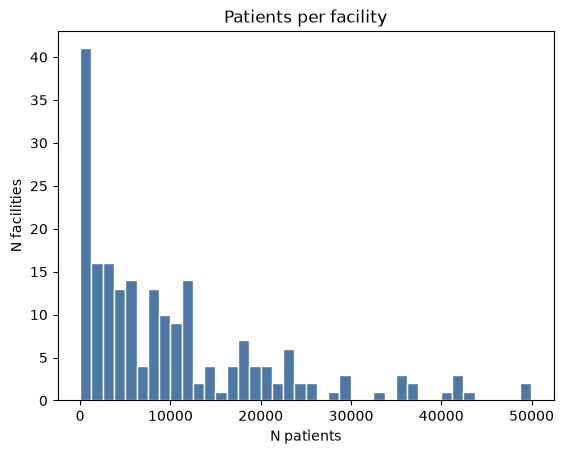

In [6]:
facility_counts = df_clean[facility_col].value_counts().rename("n_patients").reset_index()
facility_counts.columns = [facility_col, "n_patients"]

fig, ax = plt.subplots()
ax.hist(facility_counts["n_patients"], bins=40, color="#4E79A7", edgecolor="white")
ax.set_title("Patients per facility")
ax.set_xlabel("N patients")
ax.set_ylabel("N facilities")
plt.show()

In [8]:
keep_facilities = facility_counts.loc[facility_counts["n_patients"] >= 30, facility_col]

df_clean = df_clean[df_clean[facility_col].isin(keep_facilities)]

n_facilities_kept = df_clean[facility_col].nunique()
print(n_facilities_kept)

assert 150 <= n_facilities_kept <= 210, (
    f"Expected ~201 facilities after cutoff, got {n_facilities_kept}."
)

201


In [9]:
sampled_parts = []
for fac_id, group in df_clean.groupby(facility_col):
    n = min(len(group), 500)
    sampled_parts.append(group.sample(n=n, random_state=123))

df_sampled = pd.concat(sampled_parts, ignore_index=True)

del df_clean, sampled_parts
gc.collect()

print(len(df_sampled))
print(df_sampled[facility_col].value_counts().describe())

assert len(df_sampled) > 50_000, (
    f"Expected roughly 90-100K rows after capping, got {len(df_sampled)}."
)

94289
count    201.000000
mean     469.099502
std       96.957259
min       32.000000
25%      500.000000
50%      500.000000
75%      500.000000
max      500.000000
Name: count, dtype: float64


## 4. Define outcome variable and clean Length of Stay

**Outcome — Total Charges:** chosen for strong between-facility variation (institutional pricing policy), giving a stronger hierarchical story than Length of Stay or Total Costs alone.

**Length of Stay** (now a predictor, per team decision) needs cleaning first — SPARCS top-codes very long stays as `"120+"` (text), so it loads as a string. The `+` is stripped and the value treated as exactly 120 — a simplification worth flagging as a limitation (true stays could be longer, but the data doesn't record beyond that threshold).

Note: including `length_of_stay` as a predictor will likely shrink the estimated facility effect somewhat, since LOS mechanically drives charges — some of what would otherwise look like "facility charges more" gets attributed to "facility keeps patients longer" instead. Worth a sentence on this in the methodology writeup.

In [10]:
df_sampled["Length of Stay"] = df_sampled["Length of Stay"].astype(str).str.replace(r"\+", "", regex=True)
df_sampled["Length of Stay"] = pd.to_numeric(df_sampled["Length of Stay"], errors="coerce")

print(df_sampled["Length of Stay"].describe())

count    94289.000000
mean         6.471115
std         10.259109
min          1.000000
25%          2.000000
50%          3.000000
75%          7.000000
max        120.000000
Name: Length of Stay, dtype: float64


In [11]:
assert "Total Charges" in df_sampled.columns, (
    "'Total Charges' not found — check it wasn't already renamed/dropped."
)

df_sampled = df_sampled.rename(columns={"Total Charges": "charges"})
df_sampled["charges"] = pd.to_numeric(df_sampled["charges"], errors="coerce")
df_sampled = df_sampled[df_sampled["charges"].notna() & (df_sampled["charges"] > 0)]

print(df_sampled["charges"].describe())

assert df_sampled["charges"].median() > 5000, (
    f"Median charge is {df_sampled['charges'].median():.2f} — expected "
    "roughly $28,000. Values this low suggest a units/parsing issue."
)

count    9.428900e+04
mean     5.655596e+04
std      1.194724e+05
min      7.090000e+01
25%      1.413948e+04
50%      2.899722e+04
75%      5.927165e+04
max      6.508308e+06
Name: charges, dtype: float64


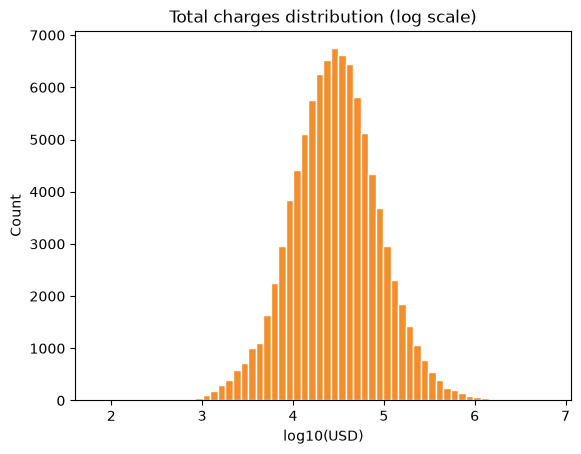

In [12]:
fig, ax = plt.subplots()
ax.hist(np.log10(df_sampled["charges"]), bins=60, color="#F28E2B", edgecolor="white")
ax.set_title("Total charges distribution (log scale)")
ax.set_xlabel("log10(USD)")
ax.set_ylabel("Count")
plt.show()

Charges should look roughly bell-shaped on the log scale (log-normal-ish) — this is the empirical justification for a Gamma(log link) likelihood in Phase 2.

## 5. Select predictors and finalize dtypes

Final predictor set (team decision): `age_group`, `admission_type`, `severity_code`, `med_surg`, `ed_indicator`, `length_of_stay`, plus `facility` as the hierarchical grouping variable.

`facility` and `severity_code` cast to clean strings here so Phase 2 never has to re-fix dtype issues (this is the fix for the earlier `1.0`-instead-of-`"000001"` labeling bug).

In [13]:
df_model = df_sampled[[
    "charges", facility_col, "Age Group", "Type of Admission",
    "APR Severity of Illness Code", "APR Medical Surgical Description",
    "Emergency Department Indicator", "Length of Stay"
]].rename(columns={
    facility_col: "facility",
    "Age Group": "age_group",
    "Type of Admission": "admission_type",
    "APR Severity of Illness Code": "severity_code",
    "APR Medical Surgical Description": "med_surg",
    "Emergency Department Indicator": "ed_indicator",
    "Length of Stay": "length_of_stay"
}).dropna().copy()

df_model["facility"] = df_model["facility"].astype(str).str.replace(r"\.0$", "", regex=True)
df_model["severity_code"] = df_model["severity_code"].astype(str)  # treat as categorical

print(df_model.shape)
print(df_model["facility"].head())  # should show clean IDs like '000001', not '1.0'
df_model.head()

assert len(df_model) > 50_000, (
    f"Expected roughly 90-100K rows in df_model, got {len(df_model)}."
)
assert not df_model["facility"].str.contains(r"\.0$").any(), (
    "facility column still has trailing '.0' — the string cleanup didn't take."
)

(94289, 8)
0    000001
1    000001
2    000001
3    000001
4    000001
Name: facility, dtype: str


Quick look at the two categorical columns most likely to be low-cardinality (binary-ish), just to know what you're working with before fitting:

In [14]:
print(df_model["med_surg"].value_counts())
print()
print(df_model["ed_indicator"].value_counts())

med_surg
Medical           77137
Surgical          17010
Not Applicable      142
Name: count, dtype: int64

ed_indicator
Y    56514
N    37775
Name: count, dtype: int64


## 6. Save processed data

Saved to `/kaggle/working/` — becomes downloadable notebook output. Download and re-upload as its own Kaggle Dataset for Phase 2.

In [15]:
df_model.to_csv("hospital_data_clean.csv", index=False)
print("saved to workspace")

saved to workspace


## Notes / decisions log

- Outcome: **Total Charges** — chosen for strong between-facility variation (institutional pricing policy).
- Predictor set (team decision): age_group, admission_type, severity_code, med_surg, ed_indicator, length_of_stay, facility.
- `length_of_stay` included as a predictor — will likely shrink the estimated facility effect somewhat, since LOS mechanically drives charges; some facility-attributable variation may instead be absorbed by this term. Noted as a deliberate modeling choice, not an oversight.
- `Length of Stay` top-coded at `"120+"` in the source data — treated as exactly 120; slightly underestimates the true right tail for the longest stays.
- Facility redaction: dropped rows with redacted/missing facility ID (see Section 2 output for exact %) — disproportionately affects small facilities, noted as a limitation.
- Small-group handling: dropped facilities with <30 patients; capped large facilities at 500 (random sample) for tractability.
- Likelihood: Gamma (log link) — justified by the log-scale histogram in Section 4.